# Customer Churn Prediction Project

## Objective
The aim of this project is to build a machine learning model that predicts whether a customer is likely to churn using customer demographic information, account details, service information and spending behaviour.

## 1. Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

The Telco Customer Churn dataset will be loaded into a pandas DataFrame for exploration and analysis.

In [2]:
df = pd.read_csv("C:/Users/soreo/OneDrive/Desktop/customer-churn-prediction/data/raw_dataset.csv.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Understanding

Before cleaning the dataset, the data will be explored to understand its structure, features, data types and any potential issues.

In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
df["Contract"].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [7]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [8]:
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [9]:
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [10]:
df.duplicated().sum()
#check for duplicates

0

# Data Understanding Findings

Initial exploration showed:

 The dataset contains 7,043 customers and 21 features
 The dataset includes demographic, account, service and spending information
 The target variable is Churn
 The TotalCharges column needs further investigation due to its incorrect data type
 No duplicate records were identified

## 4. Data Cleaning

The dataset is going to be cleaned by handling missing values, correcting data types, removing unnecessary columns and preparing the data for further analysis and modelling.

In [11]:
df_clean = df.copy()
#create a safe copy of data set

In [12]:
#check for missing values 
df_clean.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df_clean["TotalCharges"].dtype
#data type for 'TotalCharges'

dtype('O')

In [14]:
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

In [15]:
df_clean["TotalCharges"].dtype
#check if data type changed correctly

dtype('float64')

CustomerId doesnt help predict churn as its just a identifyer and doesnt explain behaviour. Therefore its an unnecessary column and will be removed. 

In [16]:
df_clean.drop("customerID", axis=1, inplace=True)

In [17]:
df_clean.duplicated().sum()

22

In [18]:
df_clean["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
df_clean["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [20]:
df_clean["PaymentMethod"].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

In [21]:
df_clean.info()
# check clean dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


The dataset decreased slightly after removing the customer identifier column

In [22]:
df.shape


(7043, 21)

In [23]:
df_clean.shape

(7043, 20)

In [24]:
df_clean.to_csv("../data/cleaned_customer_churn.csv", index=False)
#save cleaned dataset to data folder

# 5. Exploratory Data Analysis EDA
Exploratory data analysis is used to understand patterns and relationships within the dataset. This analysis will investigate customer characteristics and identify factors that may affect customer churn.

## Churn Distribution
 Before analysing customer behaviour, the distribution of the churn will be explored to understand how many customers stayed versus how many left.

In [25]:
df_clean["Churn"].value_counts()
# how many churned and how many didnt

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [26]:
df_clean["Churn"].value_counts(normalize=True) * 100
# find the number who churned and wo didnt in %

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

## Approximately 26.54% of customers have churned, and 73.46% remain with the comany. This shows that more than 1/4 of the customers leave the service, indicating a significant customer retention challenge.

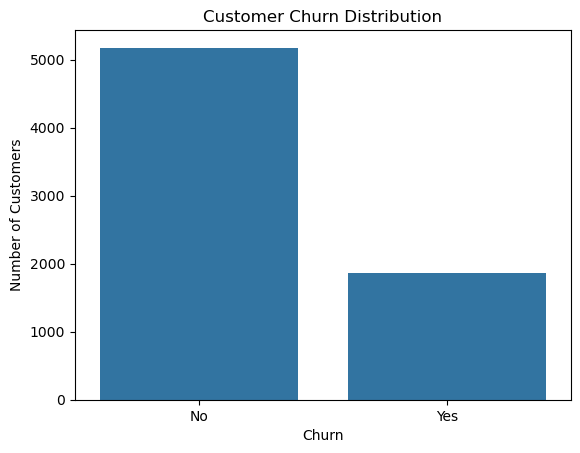

In [27]:
sns.countplot(data=df_clean, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()
#raph for clarity

## Contract Type and Customer Churn

This analysis investigates whether contract type influences customer churn.

In [28]:
pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index") * 100

# % of churn on each contract type

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


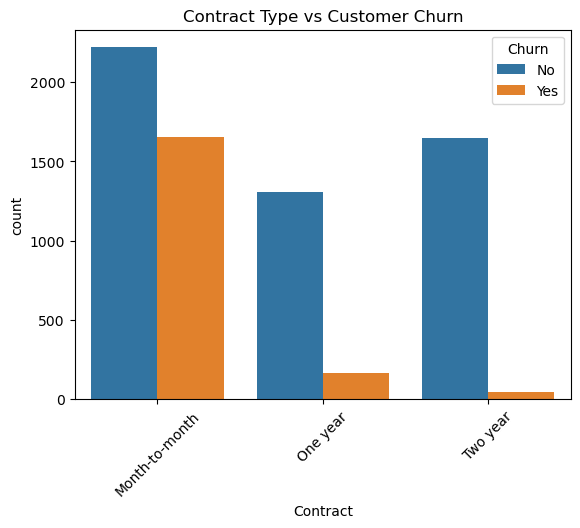

In [29]:
sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn")
plt.title("Contract Type vs Customer Churn")
plt.xticks(rotation=45)
plt.show()

## Customers on a month to month contract show the highest churn rate at 42.71% compared with 11.27% for customers on one year contracts and only 2.83% for customers on 2 year contracts. This shows that the contract length is very much strongly associated with customer retention, with longer term contracts reducing the chances of churn.

## Customer Tenure and Churn

Customer tenure is analysed to understand whether the length of time a customer has stayed with the company affects churn.

In [30]:
df_clean.groupby("Churn")["tenure"].mean()
# shows average time spent for those whoe churned and who didnt

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64

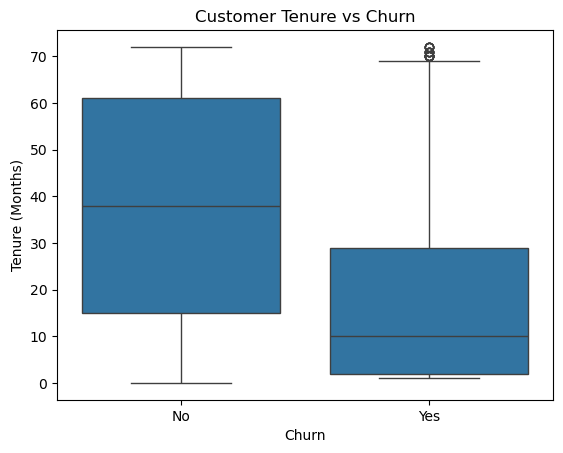

In [31]:
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="tenure")

plt.title("Customer Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()

## Customers who churn tend to have shorter relationships with the company. This means early customer experience may influence retention.

## Monthly Charges and Churn

This analysis investigates whether the amount customers pay each month is associated with customer churn.

In [32]:
df_clean.groupby("Churn")["MonthlyCharges"].mean()
# average monthly cost for those who churned v who didnt

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64

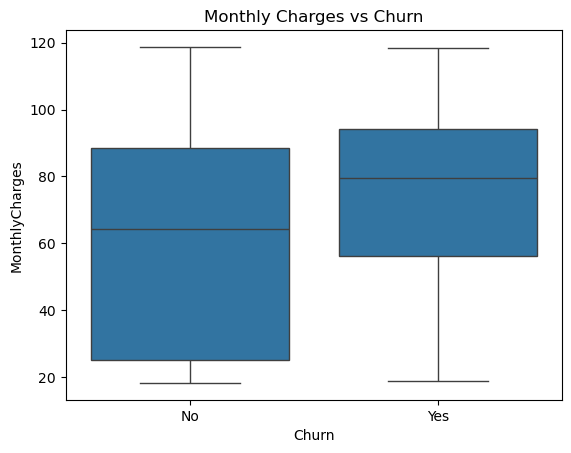

In [33]:
sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.show()

## Customers with higher monthly charges appear more likely to churn, showing that pricing may influence retention.

## Correlation Analysis

Correlation analysis is used to examine the relationships between numerical variables in the dataset. This shows relationships between numerical features.

In [34]:
correlation_matrix = df_clean.select_dtypes(include="number").corr()
correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.102411
tenure,0.016567,1.000000,0.247900,0.825880
MonthlyCharges,0.220173,0.247900,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


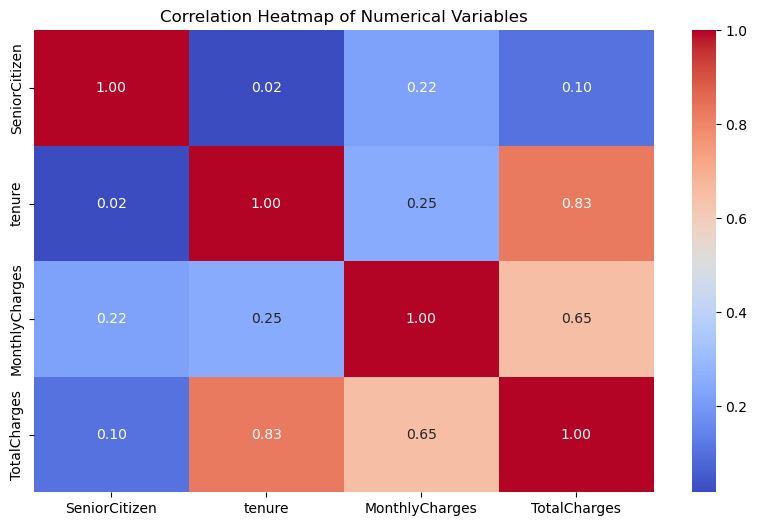

In [35]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f")

plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [36]:
df_clean.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

## EDA Findings

## EDA Findings

Key observations from the exploratory analysis:

- 26.54% of customers in the dataset have churned, representing 1,869 out of 7,043 customers.
- Customers on monthto mmonth contracts have substantially higher churn rates (42.71%) compared with customers on one year contracts (11.27%) and 2 year contracts (2.83%).
- Customers with shorter tenure appear more likely to churn.
- Monthly charges show differences between customers who churned and those who remained, suggesting a potential relationship between monthly charges and churn.
- The correlation analysis identified relationships between the numerical variables, providing additional insight into the structure of the dataset.

# 6. Feature Engineering and Model Preparation

## Define the Target Variable

The target variable for this project is customer churn and this model will use customer characteristics to predict whether a customer is likely to churn.

In [37]:
df_clean["Churn"].value_counts()
# check taget v is corect

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Separate Features and Target

The dataset is separated into input features (X) and the target variable (y). The input features contain have the customer information and the target variable represents whether the customer churned.

In [38]:
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]

In [39]:
X.shape
# check

(7043, 19)

In [40]:
y.shape

(7043,)

In [41]:
y = y.map({
    "No": 0,
    "Yes": 1})
# binary encoding
#yes = 1 and no = 0

In [42]:
y.head()
# check

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [43]:
X.select_dtypes(include="object").columns
# displays all columns in x with text

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

## Encoding Categorical Variables

The categorical variables are converted into numerical features using one hot encoding so they can be used by machine learning algorithms.

In [44]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True)
X_encoded.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [45]:
X_encoded.shape

(7043, 30)

In [46]:
X.select_dtypes(include="object").columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [47]:
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [48]:
X_encoded.shape

(7043, 30)

## Train-Test Split

The dataset is divided into a training and testing set. The training set is used to train the machine learning models, while the testing set is used to evaluate how well the models perform on unseen customer data.

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    # 20% for testing,
    random_state=42, stratify=y)
#0 = stayed,,1 = churned

In [51]:
X_train.shape

(5634, 30)

In [52]:
X_test.shape

(1409, 30)

In [53]:
y_train.shape

(5634,)

In [54]:
y_test.shape

(1409,)

In [55]:
y_train.value_counts(normalize=True) * 100

Churn
0    73.464679
1    26.535321
Name: proportion, dtype: float64

In [56]:
y_test.value_counts(normalize=True) * 100

Churn
0    73.456352
1    26.543648
Name: proportion, dtype: float64

In [57]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

## Feature Scaling

For logistic regression scaling is useful because it helps prevent variables with larger numerical values from disproportionately affecting the model's optimisation.

In [58]:
from sklearn.preprocessing import StandardScaler

In [59]:
scaler = StandardScaler()

In [60]:
X_train_scaled = scaler.fit_transform(X_train)

In [61]:
X_test_scaled = scaler.transform(X_test)

In [62]:
X_train_scaled.shape

(5634, 30)

In [63]:
X_test_scaled.shape

(1409, 30)

In [64]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

# 7. Logistic Regression Baseline Model

Logistic Regression is a classsification algorithm for predicting customer churn. Its also a good baseline, its relatively simple and interpretable.

In [65]:
from sklearn.linear_model import LogisticRegression

In [66]:
logistic_model = LogisticRegression(random_state=42)

In [67]:
X_train.isna().sum().sort_values(ascending=False).head(10)
# 8 total chares values are still missing

TotalCharges                             8
SeniorCitizen                            0
DeviceProtection_No internet service     0
PaymentMethod_Electronic check           0
PaymentMethod_Credit card (automatic)    0
PaperlessBilling_Yes                     0
Contract_Two year                        0
Contract_One year                        0
StreamingMovies_Yes                      0
StreamingMovies_No internet service      0
dtype: int64

In [68]:
df_clean[df_clean["TotalCharges"].isna()][["tenure", "MonthlyCharges", "Contract", "Churn"]]

,tenure,MonthlyCharges,Contract,Churn
488,0,52.55,Two year,No
753,0,20.25,Two year,No
936,0,80.85,Two year,No
1082,0,25.75,Two year,No
1340,0,56.05,Two year,No
3331,0,19.85,Two year,No
3826,0,25.35,Two year,No
4380,0,20.00,Two year,No
5218,0,19.70,One year,No
6670,0,73.35,Two year,No


In [69]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [70]:
df_clean["TotalCharges"].isna().sum()
#verification

0

### Additional Data Quality Check

Missing values were identified in the TotalCharges column. Investigation showed that all affected customers had a tenure of 0 months, indicating that they were new customers who had not yet accumulated any charges so the missing values were therefore replaced with 0.

In [71]:
X = df_clean.drop("Churn", axis=1)
y = df_clean["Churn"]
y = y.map({
    "No": 0,
    "Yes": 1})

In [72]:
X_encoded = pd.get_dummies(
    X,
    drop_first=True)

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [74]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [75]:
X_train.isna().sum().sum()

0

In [76]:
X_test.isna().sum().sum()

0

In [77]:
logistic_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [78]:
y_pred = logistic_model.predict(X_test_scaled)

In [79]:
y_pred[:10]
#0 = predicted to stay, 1 = predicted to churn

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 0], dtype=int64)

In [80]:
len(y_pred)

1409

## Churn Probability Predictions

In addition to predicting whether a customer is likely to churn, the model can estimate the probability of churn for each customer. These probabilities provide a measure of predicted customer risk, to now potentially prioritise the customers with hihest predicted risk.

In [81]:
y_pred_proba = logistic_model.predict_proba(X_test_scaled)

In [82]:
y_pred_proba[:5]
#[Probability of staying, Probability of churning] in %

array([[0.95501784, 0.04498216],
       [0.31676582, 0.68323418],
       [0.94345828, 0.05654172],
       [0.59219449, 0.40780551],
       [0.97833433, 0.02166567]])

In [83]:
y_pred_proba[:5]

array([[0.95501784, 0.04498216],
       [0.31676582, 0.68323418],
       [0.94345828, 0.05654172],
       [0.59219449, 0.40780551],
       [0.97833433, 0.02166567]])

## Baseline Model Performance

The Logistic regression model is evaluated using several classification metrics. 

In [84]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy * 100

80.69552874378992

In [85]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



## Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the LR model for each churn class.

In [86]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[925, 110],
       [162, 212]], dtype=int64)

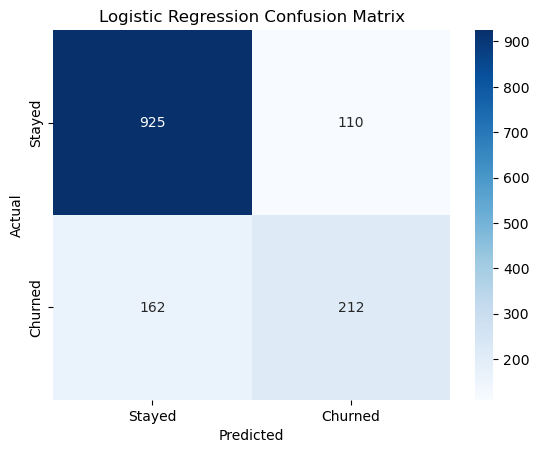

In [87]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [88]:
accuracy = accuracy_score(y_test, y_pred)
accuracy * 100

80.69552874378992

In [89]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



### Baseline Model Findings

The Logistic Regression baseline achieved 81% accuracy on the test set. The model performed better at recognising customers who stay(recall = 89%) than customers who churned (recall = 57%). This shows although the model correctly identifies the proportion of customers at risk of leaving, it still misses a significant number of actual churners.
The churn class achieved a precision of 66%, meaning that when the model predicted a customer would churn, the prediction was correct in approximately two-thirds of cases.
These results provide a baseline for comparison with a more complex model.

In [90]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
roc_auc

0.841778397788628

### Baseline Model Conclusion

The Logistic Regression model got an accuracy of 81% and a ROC-AUC score of 0.842 on the test data.The model was better at predicting customers who stayed than customers who left. It correctly identified 212 out of 374 customers who churned, but missed 162 of them. This shows that the model is able to predict churn fairly well, but there is still room for improvement. I will use a Random Forest model next to see if the predictions can be improved.

# 8. Random Forest Model
Random Forest is used as a second model to compare its performance with the logistic regression baseline.

In [91]:
from sklearn.ensemble import RandomForestClassifier

In [92]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

In [93]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [94]:
rf_pred = random_forest.predict(X_test)

In [95]:
rf_pred_proba = random_forest.predict_proba(X_test)

In [96]:
rf_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [97]:
from sklearn.ensemble import RandomForestClassifier

In [98]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42)

In [99]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [100]:
rf_pred = random_forest.predict(X_test)

In [101]:
rf_pred_proba = random_forest.predict_proba(X_test)

In [102]:
rf_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [103]:
feature_importance = random_forest.feature_importances_

In [104]:
feature_names = X_train.columns

In [105]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False)
importance_df.head(10)

,Feature,Importance
3,TotalCharges,0.191149
1,tenure,0.174795
2,MonthlyCharges,0.169026
28,PaymentMethod_Electronic check,0.039095
10,InternetService_Fiber optic,0.037259
25,Contract_Two year,0.029864
13,OnlineSecurity_Yes,0.029774
4,gender_Male,0.028501
26,PaperlessBilling_Yes,0.025097
19,TechSupport_Yes,0.023192


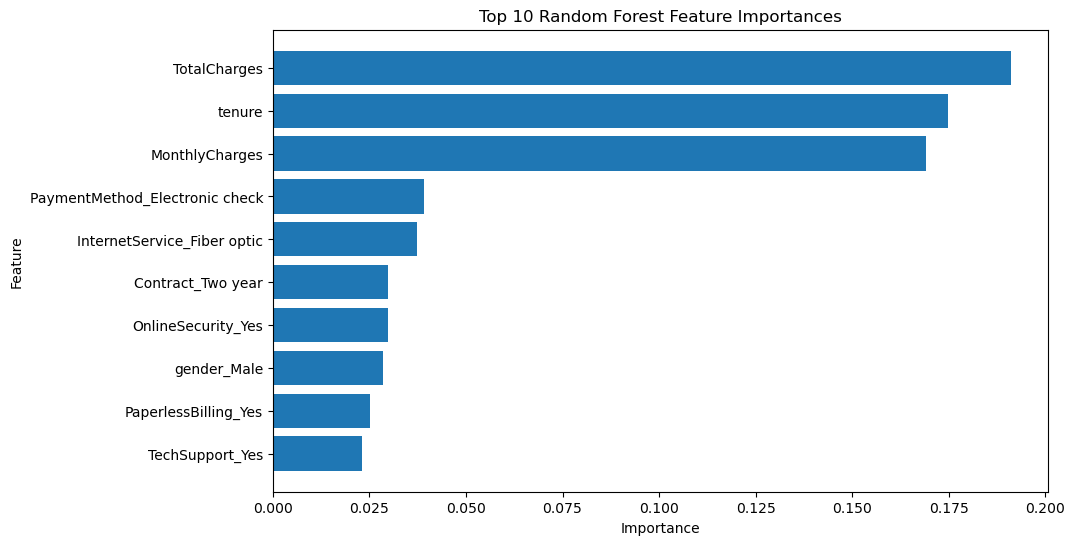

In [106]:
plt.figure(figsize=(10, 6))
plt.barh(
    importance_df.head(10)["Feature"],
    importance_df.head(10)["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [107]:
from sklearn.metrics import accuracy_score
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_accuracy * 100

78.49538679914833

In [108]:
from sklearn.metrics import classification_report
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.50      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



In [109]:
rf_cm = confusion_matrix(y_test, rf_pred)

rf_cm

array([[920, 115],
       [188, 186]], dtype=int64)

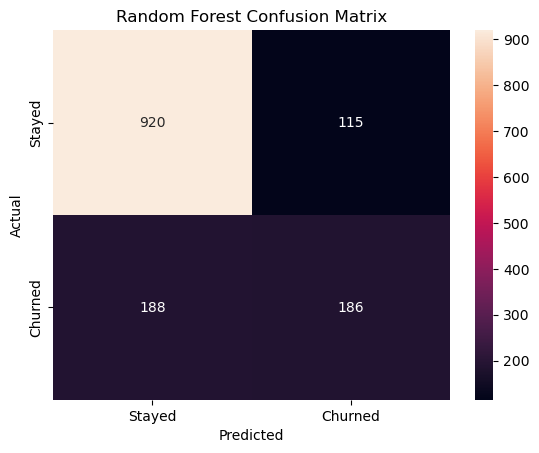

In [110]:
sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [111]:
rf_roc_auc = roc_auc_score(
    y_test,
    rf_pred_proba[:, 1])
rf_roc_auc

0.8253313182980704

### Random Forest Findings

The random forest model achieved an accuracy of 78.5% and a ROC AUC score of 0.825. It correctly identified 50% of the customers who actually churned. This was lower than the logistic regression model which identified 57% of actual churners. The random forest model also had a lower accuracy and ROC AUC score than logistic regression. Based on these results, logistic regression performed better on this dataset.

# 9. Model Comparison

The two models were compared using accuracy, precision, recall, F1score and ROC AUC to see which model performed better at predicting customer churn.

In [112]:
from sklearn.metrics import precision_score, recall_score, f1_score
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_score(y_test, y_pred), accuracy_score(y_test, rf_pred)],
    "Precision": [precision_score(y_test, y_pred), precision_score(y_test, rf_pred)],
    "Recall": [recall_score(y_test, y_pred), recall_score(y_test, rf_pred)],
    "F1-Score": [f1_score(y_test, y_pred), f1_score(y_test, rf_pred)],
    "ROC-AUC": [roc_auc, rf_roc_auc]
})
model_comparison.round(3)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.807,0.658,0.567,0.609,0.842
1,Random Forest,0.785,0.618,0.497,0.551,0.825


In [113]:
# conver to percentage
model_comparison_display = model_comparison.copy()
model_comparison_display["Accuracy"] = model_comparison_display["Accuracy"] * 100
model_comparison_display["Precision"] = model_comparison_display["Precision"] * 100
model_comparison_display["Recall"] = model_comparison_display["Recall"] * 100
model_comparison_display["F1-Score"] = model_comparison_display["F1-Score"] * 100
model_comparison_display["ROC-AUC"] = model_comparison_display["ROC-AUC"] * 100
model_comparison_display.round(2)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,80.7,65.84,56.68,60.92,84.18
1,Random Forest,78.5,61.79,49.73,55.11,82.53


### Model Comparison Conclusion

Logistic regression performed better than random forest on this dataset. It had higher accuracy, precision, recall, F1score and ROC AUC.The logistic regression model also had a higher churn recall of 57%, compared with 50% for random forest. This means it was better at identifying customers who actually churned.
Based on these results, logistic regression was the better performing model for this project.

# 10. Business Insights & Recommendations

This section summarises the main findings from the data analysis and machine learning models and considers what the company could do to reduce customer churn.

### Contract Type

Month-to-month customers had a much higher churn rate than customers on longer contracts. The churn rate was 42.71% for month-to-month customers compared with 11.27% for one-year contracts and 2.83% for two-year contracts.

This suggests that month-to-month customers may be a group that the company should focus on. The company could consider offering incentives for customers to move to longer contracts or providing targeted retention offers.

### Tenure

Customers with shorter tenure appeared more likely to churn than customers who had been with the company for longer. Tenure was also one of the most important features in the random forest model, with an importance score of 17.5%.

This suggests that newer customers may need more attention from the company. Improving the onboarding experience and providing additional support during the first few months could help the company figure out ways to improve customer retention.

### Monthly Charges

MonthlyCharges was one of the most important features in the random forest model, with an importance score of 16.9%. The exploratory analysis also suggested that churn behaviour varied across different monthly charge levels.

This shows us thata customers spending may be an important factor when predicting churn. The company could investigate whether customers feel they are receiving enough value for the amount they pay and explore targeted offers for customers at higher risk of leaving.

### Services and Payment Methods

The exploratory analysis showed differences in churn behaviour across services and payment methods. Features such as electronic check, Fiber fptic internet, online security and Tech support also appeared among the most important variables in the random forest model.

This suggests that customer services and payment preferences might be useful when identifying customers at risk of churn. The company could investigate these groups further to understand whether service quality, customer experience or other factors are influencing retention.

## Overall Recommendation

Based on the analysis, the company should focus its retention efforts on customers who may be at higher risk of churn, particularly those on monthtomonth contracts and customers with shorter tenure. The machine learning models showed that factors such as tenure, total charges, monthly charges, services and payment methods were useful when predicting churn. By using these insights, the company may be able to identify customers at risk of churning earlier and take good action to improve retention.

## Limitations

This analysis identifies patterns and relationships within the dataset but does not prove that these factors directly cause customer churn. Also, the machine learning models were tested on a specific dataset so the performance may differ when applied to new data or customers from different companies.